In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup
import bs4
pd.options.mode.chained_assignment = None  # default='warn'

#### Constants 

In [19]:
seasons = [
    "2013-14",
    "2014-15",
    "2015-16",
    "2016-17",
    "2017-18",
    "2018-19",
    "2019-20",
    "2020-21",
    "2021-22",
    "2022-23",
]

cols = [
    "W_PCT",
    "FGM",
    "FGA",
    "FG_PCT",
    "FG3M",
    "FG3A",
    "FG3_PCT",
    "FTM",
    "FTA",
    "FT_PCT",
    "OREB",
    "DREB",
    "REB",
    "AST",
    "TOV",
    "STL",
    "BLK",
    "BLKA",
    "PF",
    "PFD",
    "PTS",
    "PLUS_MINUS",
    "W_PCT_RANK",
    "MIN_RANK",
    "FGM_RANK",
    "FGA_RANK",
    "FG_PCT_RANK",
    "FG3M_RANK",
    "FG3A_RANK",
    "FG3_PCT_RANK",
    "FTM_RANK",
    "FTA_RANK",
    "FT_PCT_RANK",
    "OREB_RANK",
    "DREB_RANK",
    "REB_RANK",
    "AST_RANK",
    "TOV_RANK",
    "STL_RANK",
    "BLK_RANK",
    "FG3M_RANK",
    "FG3A_RANK",
    "FG3_PCT_RANK",
    "FTM_RANK",
    "FTA_RANK",
    "FT_PCT_RANK",
    "OREB_RANK",
    "DREB_RANK",
    "REB_RANK",
    "AST_RANK",
    "TOV_RANK",
    "STL_RANK",
    "BLK_RANK",
    "BLKA_RANK",
    "PF_RANK",
    "PFD_RANK",
    "PTS_RANK",
    "PLUS_MINUS_RANK",
    "OFF_RATING",
    "DEF_RATING",
    "NET_RATING",
    "AST_PCT",
    "AST_TO",
    "AST_RATIO",
    "OREB_PCT",
    "DREB_PCT",
    "REB_PCT",
    "TM_TOV_PCT",
    "EFG_PCT",
    "TS_PCT",
    "E_PACE",
    "PACE",
    "PACE_PER40",
    "POSS",
    "PIE",
    "OFF_RATING_RANK",
    "DEF_RATING_RANK",
    "NET_RATING_RANK",
    "AST_PCT_RANK",
    "AST_TO_RANK",
    "AST_RATIO_RANK",
    "OREB_PCT_RANK",
    "DREB_PCT_RANK",
    "REB_PCT_RANK",
    "TM_TOV_PCT_RANK",
    "EFG_PCT_RANK",
    "TS_PCT_RANK",
    "PACE_RANK",
    "PIE_RANK",
    "PCT_FGA_2PT",
    "PCT_FGA_3PT",
    "PCT_PTS_2PT",
    "PCT_PTS_2PT_MR",
    "PCT_PTS_3PT",
    "PCT_PTS_FB",
    "PCT_PTS_FT",
    "PCT_PTS_OFF_TOV",
    "PCT_PTS_PAINT",
    "PCT_AST_2PM",
    "PCT_UAST_2PM",
    "PCT_AST_3PM",
    "PCT_UAST_3PM",
    "PCT_AST_FGM",
    "PCT_UAST_FGM",
    "PCT_FGA_2PT_RANK",
    "PCT_FGA_3PT_RANK",
    "PCT_PTS_2PT_RANK",
    "PCT_PTS_2PT_MR_RANK",
    "PCT_PTS_3PT_RANK",
    "PCT_PTS_FB_RANK",
    "PCT_PTS_FT_RANK",
    "PCT_PTS_OFF_TOV_RANK",
    "PCT_PTS_PAINT_RANK",
    "PCT_AST_2PM_RANK",
    "PCT_UAST_2PM_RANK",
    "PCT_AST_3PM_RANK",
    "PCT_UAST_3PM_RANK",
    "PCT_AST_FGM_RANK",
    "PCT_UAST_FGM_RANK",
    "OPP_FGM",
    "OPP_FGA",
    "OPP_FG_PCT",
    "OPP_FG3M",
    "OPP_FG3A",
    "OPP_FG3_PCT",
    "OPP_FTM",
    "OPP_FTA",
    "OPP_FT_PCT",
    "OPP_OREB",
    "OPP_DREB",
    "OPP_REB",
    "OPP_AST",
    "OPP_TOV",
    "OPP_STL",
    "OPP_BLK",
    "OPP_BLKA",
    "OPP_PF",
    "OPP_PFD",
    "OPP_PTS",
    "OPP_FGM_RANK",
    "OPP_FGA_RANK",
    "OPP_FG_PCT_RANK",
    "OPP_FG3M_RANK",
    "OPP_FG3A_RANK",
    "OPP_FG3_PCT_RANK",
    "OPP_FTM_RANK",
    "OPP_FTA_RANK",
    "OPP_FT_PCT_RANK",
    "OPP_OREB_RANK",
    "OPP_DREB_RANK",
    "OPP_REB_RANK",
    "OPP_AST_RANK",
    "OPP_TOV_RANK",
    "OPP_STL_RANK",
    "OPP_BLK_RANK",
    "OPP_BLKA_RANK",
    "OPP_PF_RANK",
    "OPP_PFD",
    "OPP_PTS_RANK",
    "OPP_PTS_OFF_TOV",
    "OPP_PTS_2ND_CHANCE",
    "OPP_PTS_FB",
    "OPP_PTS_PAINT",
    "OPP_PTS_OFF_TOV_RANK",
    "OPP_PTS_2ND_CHANCE_RANK",
    "OPP_PTS_FB_RANK",
    "OPP_PTS_PAINT_RANK",
    "LAST_10_W_PCT",
    "TEAM_POWER",
    "W_PCT1",
    "FGM1",
    "FGA1",
    "FG_PCT1",
    "FG3M1",
    "FG3A1",
    "FG3_PCT1",
    "FTM1",
    "FTA1",
    "FT_PCT1",
    "OREB1",
    "DREB1",
    "REB1",
    "AST1",
    "TOV1",
    "STL1",
    "BLK1",
    "BLKA1",
    "PF1",
    "PFD1",
    "PTS1",
    "PLUS_MINUS1",
    "W_PCT_RANK1",
    "MIN_RANK1",
    "FGM_RANK1",
    "FGA_RANK1",
    "FG_PCT_RANK1",
    "FG3M_RANK1",
    "FG3A_RANK1",
    "FG3_PCT_RANK1",
    "FTM_RANK1",
    "FTA_RANK1",
    "FT_PCT_RANK1",
    "OREB_RANK1",
    "DREB_RANK1",
    "REB_RANK1",
    "AST_RANK1",
    "TOV_RANK1",
    "STL_RANK1",
    "BLK_RANK1",
    "FG3M_RANK1",
    "FG3A_RANK1",
    "FG3_PCT_RANK1",
    "FTM_RANK1",
    "FTA_RANK1",
    "FT_PCT_RANK1",
    "OREB_RANK1",
    "DREB_RANK1",
    "REB_RANK1",
    "AST_RANK1",
    "TOV_RANK1",
    "STL_RANK1",
    "BLK_RANK1",
    "BLKA_RANK1",
    "PF_RANK1",
    "PFD_RANK1",
    "PTS_RANK1",
    "PLUS_MINUS_RANK1",
    "OFF_RATING1",
    "DEF_RATING1",
    "NET_RATING1",
    "AST_PCT1",
    "AST_TO1",
    "AST_RATIO1",
    "OREB_PCT1",
    "DREB_PCT1",
    "REB_PCT1",
    "TM_TOV_PCT1",
    "EFG_PCT1",
    "TS_PCT1",
    "E_PACE1",
    "PACE1",
    "PACE_PER401",
    "POSS1",
    "PIE1",
    "OFF_RATING_RANK1",
    "DEF_RATING_RANK1",
    "NET_RATING_RANK1",
    "AST_PCT_RANK1",
    "AST_TO_RANK1",
    "AST_RATIO_RANK1",
    "OREB_PCT_RANK1",
    "DREB_PCT_RANK1",
    "REB_PCT_RANK1",
    "TM_TOV_PCT_RANK1",
    "EFG_PCT_RANK1",
    "TS_PCT_RANK1",
    "PACE_RANK1",
    "PIE_RANK1",
    "PCT_FGA_2PT1",
    "PCT_FGA_3PT1",
    "PCT_PTS_2PT1",
    "PCT_PTS_2PT_MR1",
    "PCT_PTS_3PT1",
    "PCT_PTS_FB1",
    "PCT_PTS_FT1",
    "PCT_PTS_OFF_TOV1",
    "PCT_PTS_PAINT1",
    "PCT_AST_2PM1",
    "PCT_UAST_2PM1",
    "PCT_AST_3PM1",
    "PCT_UAST_3PM1",
    "PCT_AST_FGM1",
    "PCT_UAST_FGM1",
    "PCT_FGA_2PT_RANK1",
    "PCT_FGA_3PT_RANK1",
    "PCT_PTS_2PT_RANK1",
    "PCT_PTS_2PT_MR_RANK1",
    "PCT_PTS_3PT_RANK1",
    "PCT_PTS_FB_RANK1",
    "PCT_PTS_FT_RANK1",
    "PCT_PTS_OFF_TOV_RANK1",
    "PCT_PTS_PAINT_RANK1",
    "PCT_AST_2PM_RANK1",
    "PCT_UAST_2PM_RANK1",
    "PCT_AST_3PM_RANK1",
    "PCT_UAST_3PM_RANK1",
    "PCT_AST_FGM_RANK1",
    "PCT_UAST_FGM_RANK1",
    "OPP_FGM1",
    "OPP_FGA1",
    "OPP_FG_PCT1",
    "OPP_FG3M1",
    "OPP_FG3A1",
    "OPP_FG3_PCT1",
    "OPP_FTM1",
    "OPP_FTA1",
    "OPP_FT_PCT1",
    "OPP_OREB1",
    "OPP_DREB1",
    "OPP_REB1",
    "OPP_AST1",
    "OPP_TOV1",
    "OPP_STL1",
    "OPP_BLK1",
    "OPP_BLKA1",
    "OPP_PF1",
    "OPP_PFD1",
    "OPP_PTS1",
    "OPP_FGM_RANK1",
    "OPP_FGA_RANK1",
    "OPP_FG_PCT_RANK1",
    "OPP_FG3M_RANK1",
    "OPP_FG3A_RANK1",
    "OPP_FG3_PCT_RANK1",
    "OPP_FTM_RANK1",
    "OPP_FTA_RANK1",
    "OPP_FT_PCT_RANK1",
    "OPP_OREB_RANK1",
    "OPP_DREB_RANK1",
    "OPP_REB_RANK1",
    "OPP_AST_RANK1",
    "OPP_TOV_RANK1",
    "OPP_STL_RANK1",
    "OPP_BLK_RANK1",
    "OPP_BLKA_RANK1",
    "OPP_PF_RANK1",
    "OPP_PFD1",
    "OPP_PTS_RANK1",
    "OPP_PTS_OFF_TOV1",
    "OPP_PTS_2ND_CHANCE1",
    "OPP_PTS_FB1",
    "OPP_PTS_PAINT1",
    "OPP_PTS_OFF_TOV_RANK1",
    "OPP_PTS_2ND_CHANCE_RANK1",
    "OPP_PTS_FB_RANK1",
    "OPP_PTS_PAINT_RANK1",
    "LAST_10_W_PCT1",
    "TEAM_POWER1",
    "HOME_TEAM_WIN",
    "HOME_TEAM_NAME",
    "AWAY_TEAM_NAME",
    "DATE",
]

base_cols = [
    "W_PCT",
    "FGM",
    "FGA",
    "FG_PCT",
    "FG3M",
    "FG3A",
    "FG3_PCT",
    "FTM",
    "FTA",
    "FT_PCT",
    "OREB",
    "DREB",
    "REB",
    "AST",
    "TOV",
    "STL",
    "BLK",
    "BLKA",
    "PF",
    "PFD",
    "PTS",
    "PLUS_MINUS",
    "W_PCT_RANK",
    "MIN_RANK",
    "FGM_RANK",
    "FGA_RANK",
    "FG_PCT_RANK",
    "FG3M_RANK",
    "FG3A_RANK",
    "FG3_PCT_RANK",
    "FTM_RANK",
    "FTA_RANK",
    "FT_PCT_RANK",
    "OREB_RANK",
    "DREB_RANK",
    "REB_RANK",
    "AST_RANK",
    "TOV_RANK",
    "STL_RANK",
    "BLK_RANK",
    "FG3M_RANK",
    "FG3A_RANK",
    "FG3_PCT_RANK",
    "FTM_RANK",
    "FTA_RANK",
    "FT_PCT_RANK",
    "OREB_RANK",
    "DREB_RANK",
    "REB_RANK",
    "AST_RANK",
    "TOV_RANK",
    "STL_RANK",
    "BLK_RANK",
    "BLKA_RANK",
    "PF_RANK",
    "PFD_RANK",
    "PTS_RANK",
    "PLUS_MINUS_RANK",
]

advanced_cols = [
    "OFF_RATING",
    "DEF_RATING",
    "NET_RATING",
    "AST_PCT",
    "AST_TO",
    "AST_RATIO",
    "OREB_PCT",
    "DREB_PCT",
    "REB_PCT",
    "TM_TOV_PCT",
    "EFG_PCT",
    "TS_PCT",
    "E_PACE",
    "PACE",
    "PACE_PER40",
    "POSS",
    "PIE",
    "OFF_RATING_RANK",
    "DEF_RATING_RANK",
    "NET_RATING_RANK",
    "AST_PCT_RANK",
    "AST_TO_RANK",
    "AST_RATIO_RANK",
    "OREB_PCT_RANK",
    "DREB_PCT_RANK",
    "REB_PCT_RANK",
    "TM_TOV_PCT_RANK",
    "EFG_PCT_RANK",
    "TS_PCT_RANK",
    "PACE_RANK",
    "PIE_RANK",
]

scoring_cols = [
    "PCT_FGA_2PT",
    "PCT_FGA_3PT",
    "PCT_PTS_2PT",
    "PCT_PTS_2PT_MR",
    "PCT_PTS_3PT",
    "PCT_PTS_FB",
    "PCT_PTS_FT",
    "PCT_PTS_OFF_TOV",
    "PCT_PTS_PAINT",
    "PCT_AST_2PM",
    "PCT_UAST_2PM",
    "PCT_AST_3PM",
    "PCT_UAST_3PM",
    "PCT_AST_FGM",
    "PCT_UAST_FGM",
    "PCT_FGA_2PT_RANK",
    "PCT_FGA_3PT_RANK",
    "PCT_PTS_2PT_RANK",
    "PCT_PTS_2PT_MR_RANK",
    "PCT_PTS_3PT_RANK",
    "PCT_PTS_FB_RANK",
    "PCT_PTS_FT_RANK",
    "PCT_PTS_OFF_TOV_RANK",
    "PCT_PTS_PAINT_RANK",
    "PCT_AST_2PM_RANK",
    "PCT_UAST_2PM_RANK",
    "PCT_AST_3PM_RANK",
    "PCT_UAST_3PM_RANK",
    "PCT_AST_FGM_RANK",
    "PCT_UAST_FGM_RANK",
]

opponent_cols = [
    "OPP_FGM",
    "OPP_FGA",
    "OPP_FG_PCT",
    "OPP_FG3M",
    "OPP_FG3A",
    "OPP_FG3_PCT",
    "OPP_FTM",
    "OPP_FTA",
    "OPP_FT_PCT",
    "OPP_OREB",
    "OPP_DREB",
    "OPP_REB",
    "OPP_AST",
    "OPP_TOV",
    "OPP_STL",
    "OPP_BLK",
    "OPP_BLKA",
    "OPP_PF",
    "OPP_PFD",
    "OPP_PTS",
    "OPP_FGM_RANK",
    "OPP_FGA_RANK",
    "OPP_FG_PCT_RANK",
    "OPP_FG3M_RANK",
    "OPP_FG3A_RANK",
    "OPP_FG3_PCT_RANK",
    "OPP_FTM_RANK",
    "OPP_FTA_RANK",
    "OPP_FT_PCT_RANK",
    "OPP_OREB_RANK",
    "OPP_DREB_RANK",
    "OPP_REB_RANK",
    "OPP_AST_RANK",
    "OPP_TOV_RANK",
    "OPP_STL_RANK",
    "OPP_BLK_RANK",
    "OPP_BLKA_RANK",
    "OPP_PF_RANK",
    "OPP_PFD",
    "OPP_PTS_RANK",
]

defense_cols = [
    "OPP_PTS_OFF_TOV",
    "OPP_PTS_2ND_CHANCE",
    "OPP_PTS_FB",
    "OPP_PTS_PAINT",
    "OPP_PTS_OFF_TOV_RANK",
    "OPP_PTS_2ND_CHANCE_RANK",
    "OPP_PTS_FB_RANK",
    "OPP_PTS_PAINT_RANK",
]

team_abbr_to_name = {
    "ATL": "Atlanta Hawks",
    "BOS": "Boston Celtics",
    "CHA": "Charlotte Hornets",
    "CHI": "Chicago Bulls",
    "CLE": "Cleveland Cavaliers",
    "DAL": "Dallas Mavericks",
    "DEN": "Denver Nuggets",
    "DET": "Detroit Pistons",
    "GSW": "Golden State Warriors",
    "HOU": "Houston Rockets",
    "IND": "Indiana Pacers",
    "LAC": "Los Angeles Clippers",
    "LAL": "Los Angeles Lakers",
    "MEM": "Memphis Grizzlies",
    "MIA": "Miami Heat",
    "MIL": "Milwaukee Bucks",
    "MIN": "Minnesota Timberwolves",
    "NOP": "New Orleans Pelicans",
    "NYK": "New York Knicks",
    "BKN": "Brooklyn Nets",
    "OKC": "Oklahoma City Thunder",
    "ORL": "Orlando Magic",
    "PHI": "Philadelphia 76ers",
    "PHX": "Phoenix Suns",
    "POR": "Portland Trail Blazers",
    "SAC": "Sacramento Kings",
    "TOR": "Toronto Raptors",
    "UTA": "Utah Jazz",
    "WAS": "Washington Wizards",
    "SAS": "San Antonio Spurs",
}

city_to_abbr_dict = {
    "Atlanta": "ATL",
    "Boston": "BOS",
    "Brooklyn": "BKN",
    "Charlotte": "CHA",
    "Chicago": "CHI",
    "Cleveland": "CLE",
    "Dallas": "DAL",
    "Denver": "DEN",
    "Detroit": "DET",
    "Golden St.": "GSW",
    "Houston": "HOU",
    "Indiana": "IND",
    "L.A. Clippers": "LAC",
    "L.A. Lakers": "LAL",
    "Memphis": "MEM",
    "Miami": "MIA",
    "Milwaukee": "MIL",
    "Minnesota": "MIN",
    "New Orleans": "NOP",
    "New York": "NYK",
    "Oklahoma City": "OKC",
    "Orlando": "ORL",
    "Philadelphia": "PHI",
    "Phoenix": "PHO",
    "Portland": "POR",
    "Utah": "UTA",
    "San Antonio": "SAS",
    "Sacramento": "SAC",
    "Toronto": "TOR",
    "Washington": "WAS",
}

team_abbr_to_id_dict = {
    "ATL": 1610612737,
    "BOS": 1610612738,
    "CLE": 1610612739,
    "NOP": 1610612740,
    "CHI": 1610612741,
    "DAL": 1610612742,
    "DEN": 1610612743,
    "GSW": 1610612744,
    "HOU": 1610612745,
    "LAC": 1610612746,
    "LAL": 1610612747,
    "MIA": 1610612748,
    "MIL": 1610612749,
    "MIN": 1610612750,
    "BKN": 1610612751,
    "NYK": 1610612752,
    "ORL": 1610612753,
    "IND": 1610612754,
    "PHI": 1610612755,
    "PHX": 1610612756,
    "POR": 1610612757,
    "SAC": 1610612758,
    "SAS": 1610612759,
    "OKC": 1610612760,
    "TOR": 1610612761,
    "UTA": 1610612762,
    "MEM": 1610612763,
    "WAS": 1610612764,
    "DET": 1610612765,
    "CHA": 1610612766,
}

player_columns = [
    "PLAYER_NAME",
    "W_PCT_RANK",
    "FGM_RANK",
    "FGA_RANK",
    "FG_PCT_RANK",
    "REB_RANK",
    "AST_RANK",
    "TOV_RANK",
    "STL_RANK",
    "BLK_RANK",
    "PLUS_MINUS_RANK",
]

player_columns_minus_name = [
    "W_PCT_RANK",
    "FGM_RANK",
    "FGA_RANK",
    "FG_PCT_RANK",
    "REB_RANK",
    "AST_RANK",
    "TOV_RANK",
    "STL_RANK",
    "BLK_RANK",
    "PLUS_MINUS_RANK",
]

player_columns_minus_name_v2 = [
    "MIN",
    "FGM",
    "FGA",
    "FG3M",
    "FG3A",
    "REB",
    "AST",
    "STL",
    "BLK",
    "PLUS_MINUS",
]

scope = [
    "https://spreadsheets.google.com/feeds",
    "https://www.googleapis.com/auth/drive",
]

#### Helper Functions

In [20]:
from sklearn.model_selection import train_test_split

from nba_api.stats.endpoints import TeamPlayerDashboard
from nba_api.stats.static.teams import find_team_name_by_id
from nba_api.stats.endpoints import LeagueDashTeamStats

import pandas as pd
import numpy as np
import re
from datetime import date
import gspread
from oauth2client.service_account import ServiceAccountCredentials
import joblib

# def find_injuries(team_abbr) -> list:
#     """
#     Basketball reference version (less up to date)
#     """
#     df = pd.read_html("https://www.basketball-reference.com/friv/injuries.fcgi")
#     injuries = {}
#     injured_list = []
#     for index, player in df[0].iterrows():
#         if player["Team"] not in injuries:
#             if "Day To Day" in player["Description"].split("-")[0]:
#                 injuries[player["Team"]] = [[], [player["Player"]]]
#             else:
#                 injuries[player["Team"]] = [[player["Player"]], []]
#         else:
#             if "Day To Day" in player["Description"].split("-")[0]:
#                 injuries[player["Team"]][1].append(player["Player"])
#             else:  # player is out
#                 injuries[player["Team"]][0].append(player["Player"])
#     if conversion_table[team_abbr] in injuries:
#         for sublist in injuries[conversion_table[team_abbr]]:
#             injured_list.extend(sublist)
#         print(team_abbr + " injured players: ", injured_list)
#         return injured_list
#     else:
#         return []

# def get_k_features(k: int, data: pd.DataFrame) -> list:
#     X = data.drop("HOME_TEAM_WIN", axis=1)
#     y = pd.get_dummies(data, columns=["HOME_TEAM_WIN"], prefix="Result")["Result_W"]

#     k_best = SelectKBest(score_func=mutual_info_classif, k=k)
#     k_best_new = k_best.fit_transform(X, y)
#     k_best_final = X.columns[k_best.get_support()]

#     return k_best_final

# def get_k_features_forest(k: int, data: pd.DataFrame) -> list:
#     X = data.drop("HOME_TEAM_WIN", axis=1)
#     y = pd.get_dummies(data, columns=["HOME_TEAM_WIN"], prefix="Result")["Result_W"]

#     rf_model = RandomForestClassifier()
#     rf_model.fit(X, y)

#     feature_importances = rf_model.feature_importances_
#     print(len(feature_importances))
#     feature_importance_df = pd.DataFrame(
#         {"Feature": X.columns, "Importance": feature_importances}
#     )


#     feature_importance_df = feature_importance_df.sort_values(
#         by="Importance", ascending=False
#     )
#     print(len(feature_importance_df))
#     return feature_importance_df.head(k)["Feature"].tolist()


def append_data_to_sheet(sheet_name: str, data: list):
    credentials = ServiceAccountCredentials.from_json_keyfile_name(
        "api_key.json", scope
    )
    gc = gspread.authorize(credentials)

    spreadsheet = gc.open("schrodinger")
    worksheet = spreadsheet.worksheet(sheet_name)
    worksheet.append_row(data)
    print("data append completed")


def find_team_name(tag: bs4.element.Tag) -> str:
    """
    finds and returns: team_name from a bs4 tag
    """
    pattern = r">(.*?)<\/a>"
    team_name = str(tag.find_all(class_="TeamName")[0])
    team_name = re.search(pattern, team_name).group(1)
    team_name = team_name.split(">", 1)[-1]
    return team_name


def find_injuriesv2() -> dict:
    """
    CBSSports injury list (more accurate and up to date)
    returns: dict of injuries team_abbr : list of injured players
    """
    injuries = {}
    r = requests.get("https://www.cbssports.com/nba/injuries/")
    soup = BeautifulSoup(r.text, "html.parser")
    team_elements = soup.find_all(class_="TableBaseWrapper")
    for team_element in team_elements:
        team_name = find_team_name(team_element)
        team_abbr = city_to_abbr_dict[team_name]
        injuries[team_abbr] = []
        for report_element in team_element.find_all("tr", class_="TableBase-bodyTr"):
            player_name = report_element.find(
                "span", class_="CellPlayerName--long"
            ).text
            injuries[team_abbr].append(player_name)
    return injuries


def prep_training_data(data: pd.DataFrame, features) -> (list, list):
    X = data.drop("HOME_TEAM_WIN", axis=1)
    y = pd.get_dummies(data, columns=["HOME_TEAM_WIN"], prefix="Result")[
        "Result_W"
    ].values
    return X[features].values, y


def scale_scores(scores: list) -> list:
    """
    scale team power score to total of 100
    """
    total = sum(scores)
    scaled_values = [value / total * 100 for value in scores]
    return scaled_values


def calculate_team_power(team_id: int, injuries: dict) -> float:
    player_stats = TeamPlayerDashboard(
        team_id=team_id, per_mode_detailed="PerGame", season="2023-24"
    ).get_data_frames()[1]
    player_stats = player_stats.sort_values("MIN_RANK").iloc[0:8]
    player_stats["SCORE"] = player_stats[player_columns_minus_name_v2].sum(axis=1)
    scores = player_stats["SCORE"]
    player_stats["IMPORTANCE"] = scale_scores(scores)
    player_stats["IMPORTANCE"] = player_stats["IMPORTANCE"]
    team_power = 100
    team_abbr = find_team_name_by_id(team_id)["abbreviation"]
    if team_abbr in injuries:
        DNP_players_list = injuries[team_abbr]
    else:
        DNP_players_list = []
    print(team_abbr, DNP_players_list)
    for index, player in player_stats.iterrows():
        if player["PLAYER_NAME"] in DNP_players_list:
            team_power -= player["IMPORTANCE"]
    return team_power


def get_current_data() -> pd.DataFrame:
    base = LeagueDashTeamStats(
        season="2023-24",
        measure_type_detailed_defense="Base",
        per_mode_detailed="PerGame",
    ).get_data_frames()[0]
    advanced = LeagueDashTeamStats(
        season="2023-24",
        measure_type_detailed_defense="Advanced",
        per_mode_detailed="PerGame",
    ).get_data_frames()[0]
    scoring = LeagueDashTeamStats(
        season="2023-24",
        measure_type_detailed_defense="Scoring",
        per_mode_detailed="PerGame",
    ).get_data_frames()[0]
    opponent = LeagueDashTeamStats(
        season="2023-24",
        measure_type_detailed_defense="Opponent",
        per_mode_detailed="PerGame",
    ).get_data_frames()[0]
    defense = LeagueDashTeamStats(
        season="2023-24",
        measure_type_detailed_defense="Defense",
        per_mode_detailed="PerGame",
    ).get_data_frames()[0]
    last_10 = LeagueDashTeamStats(
        last_n_games=10,
        measure_type_detailed_defense="Base",
        per_mode_detailed="PerGame",
        season="2023-24",
    ).get_data_frames()[0]["W_PCT"]
    last_10.rename("LAST_10_W_PCT", inplace=True)
    return pd.concat([base, advanced, scoring, opponent, defense, last_10], axis=1)


def predict_winner(
    home_team_abbr: str,
    away_team_abbr: str,
    current_data: pd.DataFrame,
    features: list,
    pca,
    model,
    injuries: dict,
    sheet_name: str,
    game_id: str,
):
    home_team_id = team_abbr_to_id_dict[home_team_abbr]
    away_team_id = team_abbr_to_id_dict[away_team_abbr]

    current_data = current_data.loc[
        :, ~current_data.columns.duplicated()
    ]  # remove duplicate columns

    home_team_stats = current_data[
        current_data["TEAM_ID"] == home_team_id
    ]  # filter home team stats
    away_team_stats = current_data[
        current_data["TEAM_ID"] == away_team_id
    ]  # filter away team stats
    home_team_stats["TEAM_POWER"] = calculate_team_power(home_team_id, injuries)
    away_team_stats["TEAM_POWER"] = calculate_team_power(
        away_team_id, injuries
    )  # add team_power feature

    away_team_stats.columns = [col + "1" for col in away_team_stats.columns]
    home_team_stats_reset = home_team_stats.reset_index(drop=True)
    away_team_stats_reset = away_team_stats.reset_index(drop=True)

    test_data = pd.concat([home_team_stats_reset, away_team_stats_reset], axis=1)[
        features
    ].values

    scaler = joblib.load("./models/scaler.save")
    test_data = scaler.transform(test_data)
    test_data = pca.transform(test_data)
    test_data = np.array(test_data).reshape(1, -1)
    result = model.predict(test_data)
    home_team_win_percentage = result
    away_team_win_percentage = 1 - home_team_win_percentage

    data = [
            date.today().strftime("%m/%d/%Y"),
            home_team_abbr,
            away_team_abbr,
            home_team_abbr
            if home_team_win_percentage[0][0] > away_team_win_percentage[0][0]
            else away_team_abbr,
            float(home_team_win_percentage[0][0])
            if home_team_win_percentage[0][0] > away_team_win_percentage[0][0]
            else float(away_team_win_percentage[0][0]),
            game_id,
            None,
        ]
    
    append_data_to_sheet(sheet_name, data)

    print(home_team_abbr + ": " + str(home_team_win_percentage[0][0]))
    print(away_team_abbr + ": " + str(away_team_win_percentage[0][0]))

##### Combine years worth of data, drop NaNs, drop duplicate/unecessary columns

In [21]:
training_data = [
    pd.read_csv("./data/2021-22.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2021-22.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2022-23.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2022-23.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2020-21.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2020-21.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2019-20.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2019-20.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2018-19.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2018-19.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2017-18.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2017-18.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2016-17.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2016-17.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2015-16.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2015-16.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2014-15.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2014-15.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2013-14.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2013-14.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2010-11.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2010-11.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2009-10.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2009-10.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2008-09.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2008-09.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2007-08.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2007-08.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2006-07.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2006-07.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2005-06.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2005-06.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2004-05.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2004-05.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2003-04.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2003-04.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2002-03.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2002-03.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2001-02.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2001-02.csv", index_col=0).columns.duplicated()
    ],
]

training_data = pd.concat(training_data)

for col in training_data.columns:
    if ".1" in col:
        training_data.drop(columns=[col], inplace=True)
training_data.drop(columns=["HOME_TEAM_NAME", "AWAY_TEAM_NAME", "DATE"], inplace=True)
training_data.dropna(inplace=True)

##### Drop Rank columns (testing to reduce variable count/multicollinearity)

In [22]:
columns_to_drop = training_data.filter(like="RANK").columns.tolist()
training_data.drop(columns=columns_to_drop, inplace=True)

##### Drop non-rank columns

In [7]:
columns_to_keep = training_data.filter(like="RANK").columns.tolist()

columns_to_keep.append("HOME_TEAM_WIN")
columns_to_keep.append("LAST_10_W_PCT1")
columns_to_keep.append("LAST_10_W_PCT")
columns_to_keep.append("TEAM_POWER")
columns_to_keep.append("TEAM_POWER1")
training_data = training_data[columns_to_keep]

#### Prepare independent and dependent training variables

In [24]:
from sklearn.preprocessing import StandardScaler

X = training_data.drop(columns = ["HOME_TEAM_WIN"])
features = X.columns
X = X.values
y = pd.get_dummies(training_data, columns=["HOME_TEAM_WIN"], prefix="Result")[
    "Result_W"
].values

['W_PCT',
 'FGM',
 'FGA',
 'FG_PCT',
 'FG3M',
 'FG3A',
 'FG3_PCT',
 'FTM',
 'FTA',
 'FT_PCT',
 'OREB',
 'DREB',
 'REB',
 'AST',
 'TOV',
 'STL',
 'BLK',
 'BLKA',
 'PF',
 'PFD',
 'PTS',
 'PLUS_MINUS',
 'OFF_RATING',
 'DEF_RATING',
 'NET_RATING',
 'AST_PCT',
 'AST_TO',
 'AST_RATIO',
 'OREB_PCT',
 'DREB_PCT',
 'REB_PCT',
 'TM_TOV_PCT',
 'EFG_PCT',
 'TS_PCT',
 'E_PACE',
 'PACE',
 'PACE_PER40',
 'POSS',
 'PIE',
 'PCT_FGA_2PT',
 'PCT_FGA_3PT',
 'PCT_PTS_2PT',
 'PCT_PTS_2PT_MR',
 'PCT_PTS_3PT',
 'PCT_PTS_FB',
 'PCT_PTS_FT',
 'PCT_PTS_OFF_TOV',
 'PCT_PTS_PAINT',
 'PCT_AST_2PM',
 'PCT_UAST_2PM',
 'PCT_AST_3PM',
 'PCT_UAST_3PM',
 'PCT_AST_FGM',
 'PCT_UAST_FGM',
 'OPP_FGM',
 'OPP_FGA',
 'OPP_FG_PCT',
 'OPP_FG3M',
 'OPP_FG3A',
 'OPP_FG3_PCT',
 'OPP_FTM',
 'OPP_FTA',
 'OPP_FT_PCT',
 'OPP_OREB',
 'OPP_DREB',
 'OPP_REB',
 'OPP_AST',
 'OPP_TOV',
 'OPP_STL',
 'OPP_BLK',
 'OPP_BLKA',
 'OPP_PF',
 'OPP_PFD',
 'OPP_PTS',
 'OPP_PTS_OFF_TOV',
 'OPP_PTS_2ND_CHANCE',
 'OPP_PTS_FB',
 'OPP_PTS_PAINT',
 'LAST_10_W

#### Transform Data

In [25]:
from sklearn.preprocessing import MinMaxScaler

# numerical_data = X[numerical_cols]

global_scaler = MinMaxScaler()
X = global_scaler.fit_transform(X)

##### Train main model

In [31]:
from keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import tensorflow as tf

NN_model = Sequential()
NN_model.add(
    Dense(
        units=80,
        activation="relu",
        input_dim=160,
    )
)
NN_model.add(Dropout(0.5))
NN_model.add(Dense(units=40, activation="relu"))
NN_model.add(Dropout(0.5))
NN_model.add(
    Dense(
        units=1,
        activation="sigmoid",
    )
)
NN_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.5, random_state=42
)

from sklearn.decomposition import PCA

pca = PCA(n_components=160)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)
X_val = pca.transform(X_val)

history = NN_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val),
)

Epoch 1/10
246/246 [==============================] - 1s 2ms/step - loss: 0.6232 - accuracy: 0.6458 - val_loss: 0.5410 - val_accuracy: 0.7259
Epoch 2/10
246/246 [==============================] - 0s 924us/step - loss: 0.5541 - accuracy: 0.7139 - val_loss: 0.5296 - val_accuracy: 0.7320
Epoch 3/10
246/246 [==============================] - 0s 887us/step - loss: 0.5419 - accuracy: 0.7290 - val_loss: 0.5247 - val_accuracy: 0.7342
Epoch 4/10
246/246 [==============================] - 0s 897us/step - loss: 0.5363 - accuracy: 0.7275 - val_loss: 0.5228 - val_accuracy: 0.7360
Epoch 5/10
246/246 [==============================] - 0s 886us/step - loss: 0.5296 - accuracy: 0.7330 - val_loss: 0.5229 - val_accuracy: 0.7349
Epoch 6/10
246/246 [==============================] - 0s 877us/step - loss: 0.5237 - accuracy: 0.7369 - val_loss: 0.5211 - val_accuracy: 0.7336
Epoch 7/10
246/246 [==============================] - 0s 883us/step - loss: 0.5207 - accuracy: 0.7389 - val_loss: 0.5191 - val_accuracy: 0

##### Model without rank variables

Accuracy Model

In [50]:
from keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import tensorflow as tf

NN_model = Sequential()
NN_model.add(
    Dense(
        units=29,
        activation="relu",
        input_dim=56,
    )
)
NN_model.add(Dropout(0.45))
NN_model.add(Dense(units=14, activation="relu"))
NN_model.add(Dropout(0.45))
NN_model.add(
    Dense(
        units=1,
        activation="sigmoid",
    )
)
NN_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.5, random_state=42
)
y_train_numerical = y_train.astype(int)
y_val_numerical = y_val.astype(int)
from sklearn.decomposition import PCA

pca = PCA(n_components=0.99)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)
X_val = pca.transform(X_val)

y_train.shape
pca.n_components_
history = NN_model.fit(
    X_train,
    y_train_numerical,
    epochs=25,
    batch_size=64,
    validation_data=(X_val, y_val_numerical),
)

Epoch 1/25
123/123 [==============================] - 0s 2ms/step - loss: 0.6810 - accuracy: 0.5705 - val_loss: 0.6511 - val_accuracy: 0.6008
Epoch 2/25
123/123 [==============================] - 0s 979us/step - loss: 0.6425 - accuracy: 0.6186 - val_loss: 0.5955 - val_accuracy: 0.7026
Epoch 3/25
123/123 [==============================] - 0s 937us/step - loss: 0.5972 - accuracy: 0.6798 - val_loss: 0.5517 - val_accuracy: 0.7266
Epoch 4/25
123/123 [==============================] - 0s 962us/step - loss: 0.5770 - accuracy: 0.6992 - val_loss: 0.5409 - val_accuracy: 0.7330
Epoch 5/25
123/123 [==============================] - 0s 917us/step - loss: 0.5659 - accuracy: 0.7097 - val_loss: 0.5366 - val_accuracy: 0.7295
Epoch 6/25
123/123 [==============================] - 0s 922us/step - loss: 0.5538 - accuracy: 0.7173 - val_loss: 0.5320 - val_accuracy: 0.7306
Epoch 7/25
123/123 [==============================] - 0s 1ms/step - loss: 0.5568 - accuracy: 0.7208 - val_loss: 0.5304 - val_accuracy: 0.7

Precision Model

In [38]:
from keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import tensorflow as tf
from keras.metrics import Precision

precision_NN_model = Sequential()
precision_NN_model.add(
    Dense(
        units=29,
        activation="relu",
        input_dim=56,
    )
)
precision_NN_model.add(Dropout(0.45))
precision_NN_model.add(Dense(units=14, activation="relu"))
precision_NN_model.add(Dropout(0.45))
precision_NN_model.add(
    Dense(
        units=1,
        activation="sigmoid",
    )
)
precision_NN_model.compile(
    optimizer="adam", loss="binary_crossentropy", metrics=[Precision()]
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.5, random_state=42
)
y_train_numerical = y_train.astype(int)
y_val_numerical = y_val.astype(int)
from sklearn.decomposition import PCA

pca = PCA(n_components=0.99)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)
X_val = pca.transform(X_val)

y_train.shape
pca.n_components_
history = precision_NN_model.fit(
    X_train,
    y_train_numerical,
    epochs=25,
    batch_size=64,
    validation_data=(X_val, y_val_numerical),
)

Epoch 1/25
123/123 [==============================] - 1s 2ms/step - loss: 0.6737 - precision: 0.5972 - val_loss: 0.6466 - val_precision: 0.6063
Epoch 2/25
123/123 [==============================] - 0s 1ms/step - loss: 0.6322 - precision: 0.6295 - val_loss: 0.5806 - val_precision: 0.7072
Epoch 3/25
123/123 [==============================] - 0s 1ms/step - loss: 0.5864 - precision: 0.7013 - val_loss: 0.5444 - val_precision: 0.7541
Epoch 4/25
123/123 [==============================] - 0s 1ms/step - loss: 0.5680 - precision: 0.7304 - val_loss: 0.5374 - val_precision: 0.7683
Epoch 5/25
123/123 [==============================] - 0s 1ms/step - loss: 0.5587 - precision: 0.7458 - val_loss: 0.5338 - val_precision: 0.7754
Epoch 6/25
123/123 [==============================] - 0s 1ms/step - loss: 0.5531 - precision: 0.7503 - val_loss: 0.5301 - val_precision: 0.7650
Epoch 7/25
123/123 [==============================] - 0s 1ms/step - loss: 0.5564 - precision: 0.7459 - val_loss: 0.5307 - val_precision:

Recall Model

In [40]:
from keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import tensorflow as tf
from keras.metrics import Recall

recall_NN_model = Sequential()
recall_NN_model.add(
    Dense(
        units=29,
        activation="relu",
        input_dim=56,
    )
)
recall_NN_model.add(Dropout(0.45))
recall_NN_model.add(Dense(units=14, activation="relu"))
recall_NN_model.add(Dropout(0.45))
recall_NN_model.add(
    Dense(
        units=1,
        activation="sigmoid",
    )
)
recall_NN_model.compile(
    optimizer="adam", loss="binary_crossentropy", metrics=[Recall()]
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.5, random_state=42
)
y_train_numerical = y_train.astype(int)
y_val_numerical = y_val.astype(int)
from sklearn.decomposition import PCA

pca = PCA(n_components=0.99)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)
X_val = pca.transform(X_val)

y_train.shape
pca.n_components_
history = recall_NN_model.fit(
    X_train,
    y_train_numerical,
    epochs=25,
    batch_size=64,
    validation_data=(X_val, y_val_numerical),
)

Epoch 1/25
123/123 [==============================] - 1s 2ms/step - loss: 0.6828 - recall: 0.7423 - val_loss: 0.6393 - val_recall: 0.9893
Epoch 2/25
123/123 [==============================] - 0s 1ms/step - loss: 0.6374 - recall: 0.8780 - val_loss: 0.5890 - val_recall: 0.9000
Epoch 3/25
123/123 [==============================] - 0s 1ms/step - loss: 0.5928 - recall: 0.8210 - val_loss: 0.5487 - val_recall: 0.8203
Epoch 4/25
123/123 [==============================] - 0s 1ms/step - loss: 0.5750 - recall: 0.7918 - val_loss: 0.5367 - val_recall: 0.8017
Epoch 5/25
123/123 [==============================] - 0s 1ms/step - loss: 0.5714 - recall: 0.7828 - val_loss: 0.5346 - val_recall: 0.8041
Epoch 6/25
123/123 [==============================] - 0s 1ms/step - loss: 0.5598 - recall: 0.8021 - val_loss: 0.5308 - val_recall: 0.8026
Epoch 7/25
123/123 [==============================] - 0s 1ms/step - loss: 0.5570 - recall: 0.7927 - val_loss: 0.5292 - val_recall: 0.7962
Epoch 8/25
123/123 [==============

In [41]:
import pickle as pk
pk.dump(pca, open("./models/recall_pca.pkl", "wb"))

##### Model with only rank variables

In [32]:
from keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import tensorflow as tf

NN_model = Sequential()
NN_model.add(
    Dense(
        units=75,
        activation="relu",
        input_dim=150,
    )
)
NN_model.add(Dropout(0.5))
NN_model.add(Dense(units=37, activation="relu"))
NN_model.add(Dropout(0.5))
NN_model.add(
    Dense(
        units=1,
        activation="sigmoid",
    )
)
NN_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [665]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.5, random_state=42
)

from sklearn.decomposition import PCA

pca = PCA(n_components=150)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)
X_val = pca.transform(X_val)

history = NN_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val),
)

Epoch 1/10
33/33 [==============================] - 1s 9ms/step - loss: 0.6774 - accuracy: 0.5782 - val_loss: 0.6465 - val_accuracy: 0.6248
Epoch 2/10
33/33 [==============================] - 0s 4ms/step - loss: 0.6529 - accuracy: 0.6085 - val_loss: 0.6275 - val_accuracy: 0.6547
Epoch 3/10
33/33 [==============================] - 0s 4ms/step - loss: 0.6336 - accuracy: 0.6408 - val_loss: 0.6136 - val_accuracy: 0.6722
Epoch 4/10
33/33 [==============================] - 0s 4ms/step - loss: 0.6139 - accuracy: 0.6664 - val_loss: 0.6024 - val_accuracy: 0.6892
Epoch 5/10
33/33 [==============================] - 0s 4ms/step - loss: 0.6092 - accuracy: 0.6711 - val_loss: 0.5960 - val_accuracy: 0.6921
Epoch 6/10
33/33 [==============================] - 0s 4ms/step - loss: 0.6071 - accuracy: 0.6735 - val_loss: 0.5935 - val_accuracy: 0.6954
Epoch 7/10
33/33 [==============================] - 0s 4ms/step - loss: 0.5886 - accuracy: 0.6957 - val_loss: 0.5921 - val_accuracy: 0.6921
Epoch 8/10
33/33 [==

##### Visualize accuracy and errors:

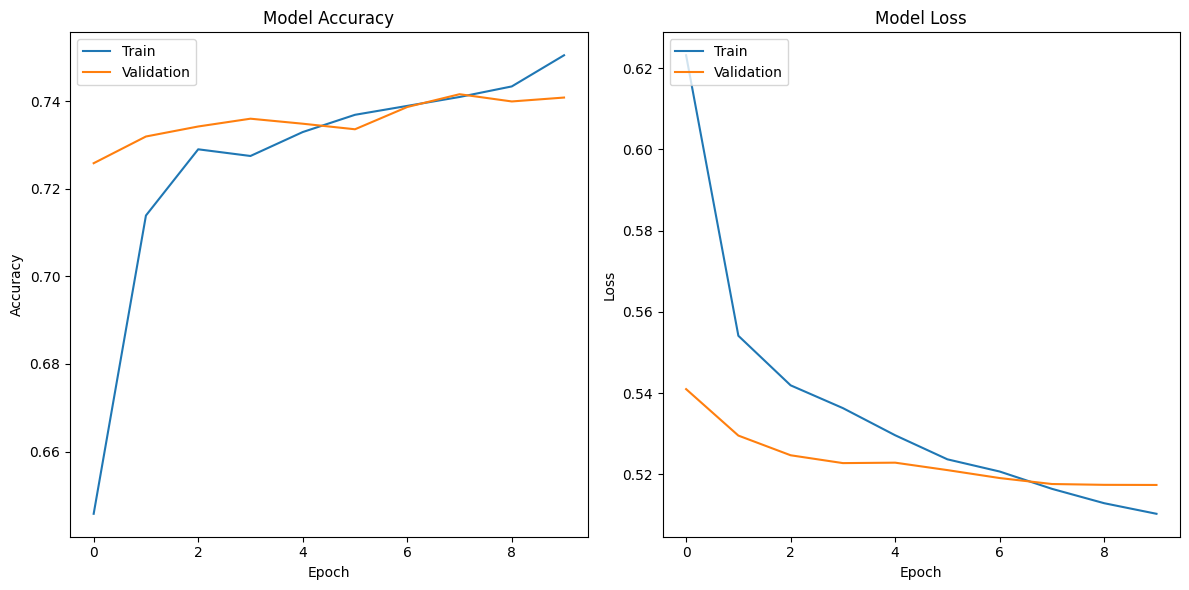

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"], loc="upper left")

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"], loc="upper left")

plt.tight_layout()
plt.show()

#### Testing model with test data

In [52]:
results = NN_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {results[0]}")
print(f"Test Accuracy: {results[1]}")

Test Loss: 0.5114496946334839
Test Accuracy: 0.7419928908348083


#### Retrieve and predict today's games

In [48]:
from nba_api.live.nba.endpoints import ScoreBoard
import time
import openpyxl
import keras
from sklearn.decomposition import PCA
import pickle as pk

features = ['W_PCT', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS', 'OFF_RATING', 'DEF_RATING', 'NET_RATING', 'AST_PCT', 'AST_TO', 'AST_RATIO', 'OREB_PCT', 'DREB_PCT', 'REB_PCT', 'TM_TOV_PCT', 'EFG_PCT', 'TS_PCT', 'E_PACE', 'PACE', 'PACE_PER40', 'POSS', 'PIE', 'PCT_FGA_2PT', 'PCT_FGA_3PT', 'PCT_PTS_2PT', 'PCT_PTS_2PT_MR', 'PCT_PTS_3PT', 'PCT_PTS_FB', 'PCT_PTS_FT', 'PCT_PTS_OFF_TOV', 'PCT_PTS_PAINT', 'PCT_AST_2PM', 'PCT_UAST_2PM', 'PCT_AST_3PM', 'PCT_UAST_3PM', 'PCT_AST_FGM', 'PCT_UAST_FGM', 'OPP_FGM', 'OPP_FGA', 'OPP_FG_PCT', 'OPP_FG3M', 'OPP_FG3A', 'OPP_FG3_PCT', 'OPP_FTM', 'OPP_FTA', 'OPP_FT_PCT', 'OPP_OREB', 'OPP_DREB', 'OPP_REB', 'OPP_AST', 'OPP_TOV', 'OPP_STL', 'OPP_BLK', 'OPP_BLKA', 'OPP_PF', 'OPP_PFD', 'OPP_PTS', 'OPP_PTS_OFF_TOV', 'OPP_PTS_2ND_CHANCE', 'OPP_PTS_FB', 'OPP_PTS_PAINT', 'LAST_10_W_PCT', 'TEAM_POWER', 'W_PCT1', 'FGM1', 'FGA1', 'FG_PCT1', 'FG3M1', 'FG3A1', 'FG3_PCT1', 'FTM1', 'FTA1', 'FT_PCT1', 'OREB1', 'DREB1', 'REB1', 'AST1', 'TOV1', 'STL1', 'BLK1', 'BLKA1', 'PF1', 'PFD1', 'PTS1', 'PLUS_MINUS1', 'OFF_RATING1', 'DEF_RATING1', 'NET_RATING1', 'AST_PCT1', 'AST_TO1', 'AST_RATIO1', 'OREB_PCT1', 'DREB_PCT1', 'REB_PCT1', 'TM_TOV_PCT1', 'EFG_PCT1', 'TS_PCT1', 'E_PACE1', 'PACE1', 'PACE_PER401', 'POSS1', 'PIE1', 'PCT_FGA_2PT1', 'PCT_FGA_3PT1', 'PCT_PTS_2PT1', 'PCT_PTS_2PT_MR1', 'PCT_PTS_3PT1', 'PCT_PTS_FB1', 'PCT_PTS_FT1', 'PCT_PTS_OFF_TOV1', 'PCT_PTS_PAINT1', 'PCT_AST_2PM1', 'PCT_UAST_2PM1', 'PCT_AST_3PM1', 'PCT_UAST_3PM1', 'PCT_AST_FGM1', 'PCT_UAST_FGM1', 'OPP_FGM1', 'OPP_FGA1', 'OPP_FG_PCT1', 'OPP_FG3M1', 'OPP_FG3A1', 'OPP_FG3_PCT1', 'OPP_FTM1', 'OPP_FTA1', 'OPP_FT_PCT1', 'OPP_OREB1', 'OPP_DREB1', 'OPP_REB1', 'OPP_AST1', 'OPP_TOV1', 'OPP_STL1', 'OPP_BLK1', 'OPP_BLKA1', 'OPP_PF1', 'OPP_PFD1', 'OPP_PTS1', 'OPP_PTS_OFF_TOV1', 'OPP_PTS_2ND_CHANCE1', 'OPP_PTS_FB1', 'OPP_PTS_PAINT1', 'LAST_10_W_PCT1', 'TEAM_POWER1']

scoreboard = ScoreBoard()
current_data = get_current_data()
injuries = find_injuriesv2()


NN_model = keras.models.load_model("./models/accuray_model.keras")
precision_NN_model = keras.models.load_model("./models/precision_model.keras")
recall_NN_model = keras.models.load_model("./models/recall_model.keras")



for game_dict in scoreboard.get_dict()["scoreboard"]["games"]:
    pca = pk.load(open("./models/accuracy_pca.pkl",'rb'))
    game_id = game_dict["gameId"]
    home_team_abbr = game_dict["homeTeam"]["teamTricode"]
    away_team_abbr = game_dict["awayTeam"]["teamTricode"]
    predict_winner(
        home_team_abbr,
        away_team_abbr,
        current_data,
        features,
        pca,
        NN_model,
        injuries,
        "accuracy",
        game_id,
    )
    time.sleep(3)

for game_dict in scoreboard.get_dict()["scoreboard"]["games"]:
    pca = pk.load(open("./models/precision_pca.pkl",'rb'))
    game_id = game_dict["gameId"]
    home_team_abbr = game_dict["homeTeam"]["teamTricode"]
    away_team_abbr = game_dict["awayTeam"]["teamTricode"]
    predict_winner(
        home_team_abbr,
        away_team_abbr,
        current_data,
        features,
        pca,
        precision_NN_model,
        injuries,
        "precision",
        game_id,
    )
    time.sleep(3)


for game_dict in scoreboard.get_dict()["scoreboard"]["games"]:
    pca = pk.load(open("./models/recall_pca.pkl",'rb'))
    game_id = game_dict["gameId"]
    home_team_abbr = game_dict["homeTeam"]["teamTricode"]
    away_team_abbr = game_dict["awayTeam"]["teamTricode"]
    predict_winner(
        home_team_abbr,
        away_team_abbr,
        current_data,
        features,
        pca,
        recall_NN_model,
        injuries,
        "recall",
        game_id,
    )
    time.sleep(3)

DET ['Cade Cunningham', 'Malcolm Cazalon']
CHA ['Gordon Hayward', 'Kyle Lowry', 'Mark Williams']
1/1 [==============================] - 0s 36ms/step
data append completed
DET: 0.49090558
CHA: 0.5090944
WAS ['Isaiah Livers']
MIN ['Mike Conley', 'Jaylen Clark']
1/1 [==============================] - 0s 14ms/step
data append completed
WAS: 0.13476904
MIN: 0.865231
MIA ['Jaime Jaquez Jr.', 'Kevin Love', 'Dru Smith']
MEM ['Luke Kennard', 'Santi Aldama', 'Derrick Rose', 'Jake LaRavia', 'Desmond Bane', 'Marcus Smart', 'Ja Morant', 'Brandon Clarke', 'Steven Adams']
1/1 [==============================] - 0s 15ms/step
data append completed
MIA: 0.7346799
MEM: 0.26532012
HOU ['Tari Eason', 'Jabari Smith', 'Reggie Bullock', "Jae'Sean Tate", 'Victor Oladipo']
POR ['Shaedon Sharpe', 'Moses Brown', 'Robert Williams III']
1/1 [==============================] - 0s 14ms/step
data append completed
HOU: 0.5389071
POR: 0.4610929
MIL []
CLE ['Ty Jerome', 'Emoni Bates', 'Darius Garland', 'Evan Mobley']
1/1 [

KeyboardInterrupt: 

#### Update truths

In [47]:
from nba_api.stats.endpoints import BoxScoreTraditionalV3

scope = [
    "https://spreadsheets.google.com/feeds",
    "https://www.googleapis.com/auth/drive",
]

credentials = ServiceAccountCredentials.from_json_keyfile_name(
    "api_key.json", scope
)
gc = gspread.authorize(credentials)
spreadsheet = gc.open("schrodinger")
worksheet = spreadsheet.worksheet("accuracy")
truths = []
for row_index, row_data in enumerate(worksheet.get_all_values()[1:], start=2):
    game_id = row_data[5]
    scoreboard = BoxScoreTraditionalV3(game_id)

    if row_data[6] == "":
        print("here")
        if (
            scoreboard.get_dict()["boxScoreTraditional"]["homeTeam"]["starters"][
                "minutes"
            ]
            == ""
        ):
            pass
        else:
            home_team_points = scoreboard.get_dict()["boxScoreTraditional"]["homeTeam"][
                "statistics"
            ]["points"]
            home_team_abbr = scoreboard.get_dict()["boxScoreTraditional"]["homeTeam"][
                "teamTricode"
            ]
            away_team_points = scoreboard.get_dict()["boxScoreTraditional"]["awayTeam"][
                "statistics"
            ]["points"]
            away_team_abbr = scoreboard.get_dict()["boxScoreTraditional"]["awayTeam"][
                "teamTricode"
            ]
            if home_team_points > away_team_points:
                differential = home_team_points - away_team_points
                worksheet.update_cell(row_index, 7, home_team_abbr)
                worksheet.update_cell(row_index, 8, differential)
                truths.append((row_index, home_team_abbr, differential))
                print("updated")
            else:
                differential = away_team_points - home_team_points
                worksheet.update_cell(row_index, 7, away_team_abbr)
                worksheet.update_cell(row_index, 8, differential)
                truths.append((row_index, away_team_abbr, differential))
                print("updated")
            time.sleep(3)

for sheet_name in ["precision", "recall"]:
    spreadsheet = gc.open("schrodinger")
    worksheet = spreadsheet.worksheet(sheet_name)
    for truth in truths:
        worksheet.update_cell(truth[0], 7, truth[1])
        worksheet.update_cell(truth[0], 8, truth[2])
        time.sleep(3)

here
updated
here
updated
here
updated
here
updated
here
updated
here
updated
here
updated


Single Game Testing

In [209]:
games = []
for game in scoreboard.get_dict()["scoreboard"]["games"]:
    print(game["gameTimeUTC"])

2024-01-23T00:00:00Z
2024-01-23T00:00:00Z
2024-01-23T00:00:00Z
2024-01-23T00:30:00Z
2024-01-23T01:00:00Z
2024-01-23T01:30:00Z
2024-01-23T02:00:00Z
2024-01-23T03:00:00Z
